# 🏅 Olympic Medal Prediction using Machine Learning

## 📜 Introduction

This project aims to develop a machine learning model to predict the number of medals a country will win in future Olympic Games. The model is trained on historical Olympic data, including demographic and performance features. The objective is to identify key factors that influence medal counts and create a reliable predictive framework for upcoming Olympic events.

---

## 1. Form a Hypothesis 🎯

The central hypothesis of this project is:

> *"A country's number of medals in the **next** Olympic Games can be predicted based on its historical Olympic performance, the number of athletes and events it participates in, and aggregated athlete demographic data such as age, height, and weight."*

This project assumes that there is a **predictable relationship** between a country's past performance and its future outcomes in the Olympic Games. The goal is to use data from previous Olympic Games to forecast how many medals a country will win in the next one.

Specifically, we believe that countries which have:

- **Consistently performed well** in the last 1–3 Olympic Games,
- **Invested in large, competitive teams** (more athletes and events),
- **Maintained stable athlete characteristics** (e.g., average age, height, weight, physical rediness),

…are more likely to continue winning medals in future Games.

---

## 2. Collecting the Data 🗂️

### Data Description 📋

The dataset contains historical Olympic participation and performance data, with the following features:

- **team**: A three-letter abbreviation representing the team (e.g., USA, GBR, CHN)
- **country**: Full name of the country
- **year**: The year of the Olympic Games
- **events**: The number of events the team participated in during that year
- **athletes**: Total number of athletes representing the team
- **age**: Average age of the athletes
- **height**: Average height of the athletes
- **weight**: Average weight of the athletes
- **medals**: Total number of medals won in the current Olympic Games *(Target variable)*
- **prev_medals**: Number of medals the team won in the previous Olympic Games
- **prev_3_medals**: Cumulative number of medals won in the past three Olympic Games

Preprocessing steps include handling missing values, normalizing numeric fields, and aggregating data at the team level for each Olympic year.

---

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures

## Functions

In [2]:
def train_and_visualize_model(X, y, model, model_name="Model", test_size=0.2, needs_scaling=True):
    """
    Complete pipeline: Train model, make predictions, and visualize performance
    
    Parameters:
    -----------
    X : array-like, feature matrix
    y : array-like, target values
    model : sklearn model instance
    model_name : str, name of the model for titles
    test_size : float, proportion for test set

    """
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    
    # Scale features if needed
    if needs_scaling:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
    else:
        X_train_scaled = X_train
        X_test_scaled = X_test
    
    model.fit(X_train_scaled, y_train)
    
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # Create visualizations
    fig = plt.figure(figsize=(18, 30))
    
    # 1. Training vs Test Performance Comparison
    ax1 = plt.subplot(4, 1, 1)
    # Training data
    ax1.scatter(y_train, y_train_pred, alpha=0.5, label='Training', 
                color='blue', s=30, edgecolor='white', linewidth=0.5)
    # Test data
    ax1.scatter(y_test, y_test_pred, alpha=0.5, label='Test', 
                color='red', s=30, marker='s', edgecolor='white', linewidth=0.5)
    
    all_values = np.concatenate([y_train, y_test, y_train_pred, y_test_pred])
    min_val, max_val = all_values.min(), all_values.max()
    ax1.plot([min_val, max_val], [min_val, max_val], 
             'k--', linewidth=2, label='Perfect Prediction')
    
    ax1.set_xlabel('Actual Values')
    ax1.set_ylabel('Predicted Values')
    ax1.set_title(f'{model_name}: Training vs Test Predictions')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Metrics Comparison Bar Chart
    ax2 = plt.subplot(4,1,2)
    metrics = ['R² Score', 'MAE', 'RMSE']
    train_metrics = [train_r2, train_mae, train_rmse]
    test_metrics = [test_r2, test_mae, test_rmse]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    ax2.bar(x - width/2, train_metrics, width, label='Training', 
            color='blue', alpha=0.7, edgecolor='black')
    ax2.bar(x + width/2, test_metrics, width, label='Test', 
            color='red', alpha=0.7, edgecolor='black')
    
    ax2.set_xlabel('Metrics')
    ax2.set_ylabel('Value')
    ax2.set_title('Model Performance Metrics')
    ax2.set_xticks(x)
    ax2.set_xticklabels(metrics)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    for i, (train_val, test_val) in enumerate(zip(train_metrics, test_metrics)):
        ax2.text(i - width/2, train_val + 0.01*max(train_metrics + test_metrics), 
                f'{train_val:.3f}', ha='center', va='bottom', fontsize=8)
        ax2.text(i + width/2, test_val + 0.01*max(train_metrics + test_metrics), 
                f'{test_val:.3f}', ha='center', va='bottom', fontsize=8)
    
    ax3 = plt.subplot(4,1,3)
    train_residuals = y_train - y_train_pred
    test_residuals = y_test - y_test_pred
    
    ax3.scatter(y_train_pred, train_residuals, alpha=0.5, 
                label='Training Residuals', color='blue', s=30)
    ax3.scatter(y_test_pred, test_residuals, alpha=0.5, 
                label='Test Residuals', color='red', s=30, marker='s')
    ax3.axhline(y=0, color='black', linestyle='--', linewidth=1)
    
    ax3.set_xlabel('Predicted Values')
    ax3.set_ylabel('Residuals (Actual - Predicted)')
    ax3.set_title('Residuals Analysis')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    ax4 = plt.subplot(4,1,4)
    train_errors = np.abs(y_train - y_train_pred)
    test_errors = np.abs(y_test - y_test_pred)
    
    bins = np.linspace(0, max(np.max(train_errors), np.max(test_errors)), 30)
    ax4.hist(train_errors, bins=bins, alpha=0.5, label='Training Errors', 
             color='blue', density=True)
    ax4.hist(test_errors, bins=bins, alpha=0.5, label='Test Errors', 
             color='red', density=True)
    
    ax4.axvline(x=np.mean(train_errors), color='blue', linestyle='--', 
                linewidth=2, label=f'Train Mean: {np.mean(train_errors):.3f}')
    ax4.axvline(x=np.mean(test_errors), color='red', linestyle='--', 
                linewidth=2, label=f'Test Mean: {np.mean(test_errors):.3f}')
    
    ax4.set_xlabel('Absolute Error')
    ax4.set_ylabel('Density')
    ax4.set_title('Error Distribution')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    print("\n" + "="*60)
    print(f"{model_name} PERFORMANCE SUMMARY")
    print("="*60)
    print(f"{'Metric':<20} {'Training':<12} {'Test':<12} {'Difference':<12}")
    print("-"*60)
    print(f"{'R² Score':<20} {train_r2:<12.4f} {test_r2:<12.4f} {train_r2-test_r2:<12.4f}")
    print(f"{'MAE':<20} {train_mae:<12.4f} {test_mae:<12.4f} {train_mae-test_mae:<12.4f}")
    print(f"{'RMSE':<20} {train_rmse:<12.4f} {test_rmse:<12.4f} {train_rmse-test_rmse:<12.4f}")
    print(f"{'Mean Abs Error':<20} {np.mean(train_errors):<12.4f} {np.mean(test_errors):<12.4f} "
          f"{np.mean(train_errors)-np.mean(test_errors):<12.4f}")
    print("="*60)
    
    # Check for overfitting
    overfit_warning = ""
    if abs(train_r2 - test_r2) > 0.1:
        overfit_warning = "⚠ Warning: Potential overfitting (large gap between train/test R²)"
    elif train_r2 > 0.95 and test_r2 < 0.8:
        overfit_warning = "⚠ Warning: Model may be overfitting (high train R², lower test R²)"
    
    if overfit_warning:
        print(f"\n{overfit_warning}")
    

In [3]:
teams = pd.read_csv('teams.csv')

In [4]:
teams.sample(15)

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
1882,TAN,Tanzania,2000,2,4,27.0,171.2,59.0,0,0.0,0.0
295,BRU,Brunei,2004,1,1,22.0,173.0,65.0,0,0.0,0.0
801,GUA,Guatemala,2008,12,13,27.5,174.4,67.6,0,0.0,0.0
1495,PAK,Pakistan,1964,29,47,26.8,173.6,71.2,16,14.0,9.3
1325,MLT,Malta,1984,6,7,26.9,171.7,69.7,0,0.0,0.0
1433,NEP,Nepal,2008,8,8,27.1,163.1,61.6,0,0.0,0.0
1814,SUI,Switzerland,1992,80,171,26.3,175.6,69.3,1,8.0,7.7
396,CHI,Chile,2016,36,47,27.1,172.7,67.0,0,0.0,1.7
1149,LCA,Saint Lucia,2004,2,2,22.5,168.5,64.0,0,0.0,0.0
81,ARG,Argentina,2016,80,232,27.5,178.7,75.2,22,19.0,39.7


In [5]:
teams.describe()

,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
count,2144.000000,2144.000000,2144.000000,2144.000000,2144.000000,2144.000000,2144.000000,2014.000000,2014.000000
mean,1994.507463,35.724813,73.693097,24.778591,173.900233,69.271595,10.556437,10.248759,9.449901
std,15.384205,49.490270,127.907577,2.808559,5.357367,7.606507,33.028143,31.951920,28.232227
min,1964.000000,1.000000,1.000000,17.000000,151.000000,43.000000,0.000000,0.000000,0.000000
25%,1984.000000,6.000000,7.000000,23.275000,170.500000,64.500000,0.000000,0.000000,0.000000
50%,1996.000000,13.000000,19.000000,24.700000,174.400000,69.400000,0.000000,0.000000,0.300000
75%,2008.000000,44.000000,70.250000,26.100000,177.300000,73.400000,4.000000,4.000000,4.650000
max,2016.000000,270.000000,839.000000,66.000000,193.000000,148.000000,442.000000,442.000000,314.000000


## 3. Reshaping the Data 📝

In this step, we focus on preparing the dataset for the modeling phase by reshaping the data and organizing the features in a meaningful order. Specifically, we rearrange the columns to ensure that the target variable, `medals`, is positioned at the end of the DataFrame. This helps improve clarity and makes the dataset more suitable for input into machine learning algorithms.

We also remove any redundant or less informative features that are not essential for predicting the number of medals. For instance, the `team` column, which only contains a three-letter code for each country, is essentially a duplicate of the `country` column and does not provide additional predictive value.

---

In [6]:
teams = teams[['country', 'year', 'events', 'athletes', 'age', 'height', 'weight', 'prev_3_medals', 'prev_medals', 'medals']]

In [7]:
teams

,country,year,events,athletes,age,height,weight,prev_3_medals,prev_medals,medals
0,Afghanistan,1964,8,8,22.0,161.0,64.2,0.0,0.0,0
1,Afghanistan,1968,5,5,23.2,170.2,70.0,0.0,0.0,0
2,Afghanistan,1972,8,8,29.0,168.3,63.8,0.0,0.0,0
3,Afghanistan,1980,11,11,23.6,168.4,63.2,0.0,0.0,0
4,Afghanistan,2004,5,5,18.6,170.8,64.8,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...
2139,Zimbabwe,2000,19,26,25.0,179.0,71.1,0.0,0.0,0
2140,Zimbabwe,2004,11,14,25.1,177.8,70.5,0.0,0.0,3
2141,Zimbabwe,2008,15,16,26.1,171.9,63.7,1.0,3.0,4
2142,Zimbabwe,2012,8,9,27.3,174.4,65.2,2.3,4.0,0


## 4. Missing Values 📄

Before proceeding with visualising, it's important to assess and handle any missing values in the dataset to ensure the integrity and reliability of the analysis.

---

In [8]:
teams.isna().mean()

country          0.000000
year             0.000000
events           0.000000
athletes         0.000000
age              0.000000
height           0.000000
weight           0.000000
prev_3_medals    0.060634
prev_medals      0.060634
medals           0.000000
dtype: float64

The only features with missing values are:
- `prev_medals`
- `prev_3_medals`

Given the relatively small percentage of missing values (~6%), and the fact that these features are potentially informative for prediction, we will **not drop any rows**. Instead, we will **impute** the missing values using a reasonable strategy:

- We will **fill missing values with 0**, assuming that countries with no prior medal records either did not participate or did not win medals in previous Olympics.
- This is a **conservative and interpretable approach** that avoids introducing bias by assuming performance.


In [9]:
teams['prev_medals'] = teams['prev_medals'].fillna(0)
teams['prev_3_medals'] = teams['prev_3_medals'].fillna(0)

## 5. Data Visualisation 📊📈

Data visualisation plays a crucial role in understanding the relationships between variables, identifying patterns, spotting outliers, and gaining insights that guide feature engineering and modeling decisions.

---

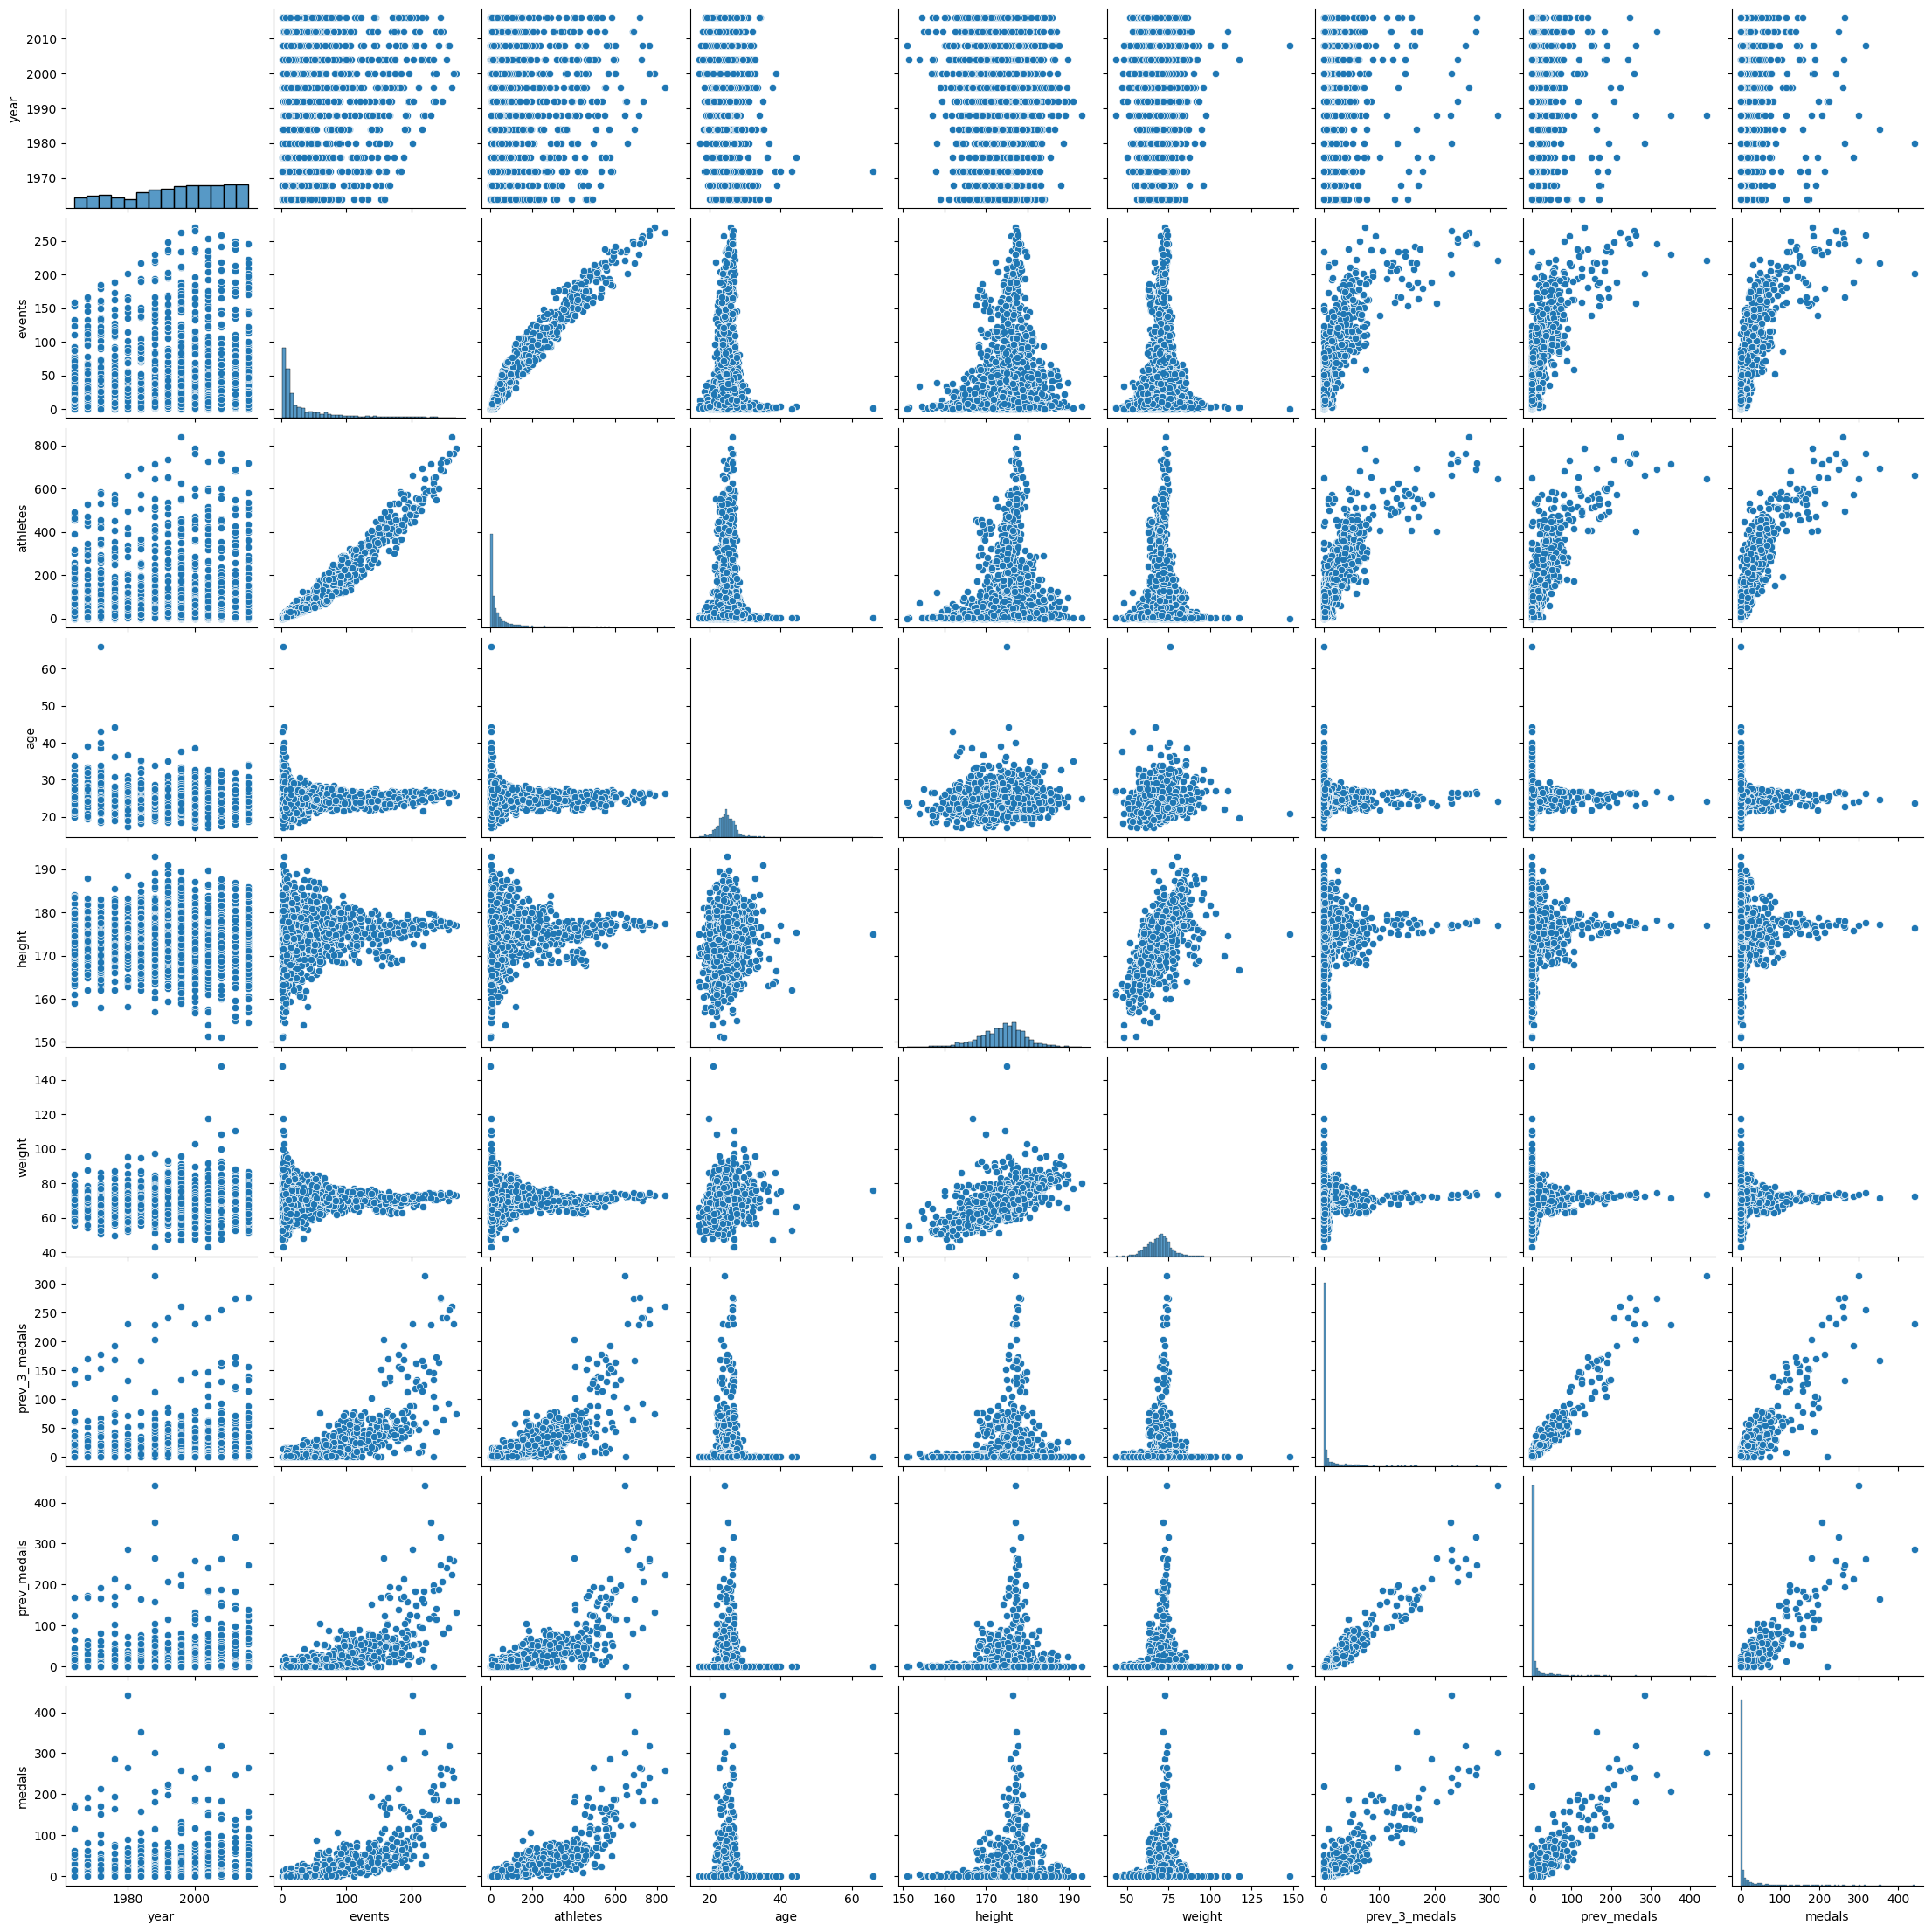

In [10]:
sns.pairplot(teams)

We can see that there is a strong linear relationship between `events` and `athletes`, between `prev_medals`, `prev_3_medals` and the target variable `medals`.
Also there exists some relationship between `events` and `prev_medals`, `prev_3_medals`, target variable `medals` and between `athletes` and `prev_medals`, `prev_3_medals`, target variable `medals. These relationships may not have a strong linear relationship, but there is some relationship.

In [11]:
teams.drop(columns="country").corr()

,year,events,athletes,age,height,weight,prev_3_medals,prev_medals,medals
year,1.000000,-0.016345,-0.056957,-0.012179,-0.001459,0.031400,0.005209,-0.002625,-0.021603
events,-0.016345,1.000000,0.976446,0.053461,0.208067,0.127031,0.763968,0.743458,0.771330
athletes,-0.056957,0.976446,1.000000,0.036358,0.186134,0.109439,0.817022,0.801140,0.840817
age,-0.012179,0.053461,0.036358,1.000000,0.173694,0.220497,0.043602,0.034685,0.025096
height,-0.001459,0.208067,0.186134,0.173694,1.000000,0.687398,0.140251,0.134798,0.141055
weight,0.031400,0.127031,0.109439,0.220497,0.687398,1.000000,0.090186,0.086787,0.090577
prev_3_medals,0.005209,0.763968,0.817022,0.043602,0.140251,0.090186,1.000000,0.968976,0.907482
prev_medals,-0.002625,0.743458,0.801140,0.034685,0.134798,0.086787,0.968976,1.000000,0.909139
medals,-0.021603,0.771330,0.840817,0.025096,0.141055,0.090577,0.907482,0.909139,1.000000


<Axes: >

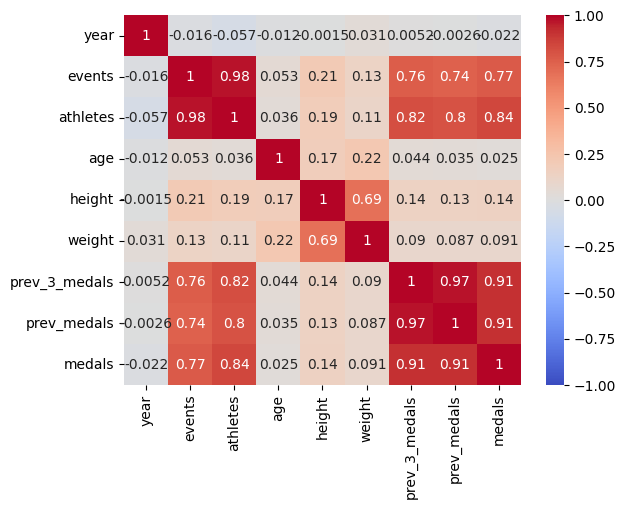

In [12]:
sns.heatmap(teams.drop(columns='country').corr(), vmin=-1, vmax=1, cmap="coolwarm", annot=True)

From this correlation matrix and **heatmap** representation of the correlation matrix we can tell that `year`, `age`, `height` and `weight` have almost **0 Pearson correlation coefficient**, meaning that they have no impact on the target variable, `medals`. On the other hand, the other features have a strong correlation indicating that they are going to help us getting a good prediction out of the model.

To avoid redundancy we are going to remove the feature `events` because of the **0.976** correlation coefficient with `athletes`, and that `athletes` have a slightly higher correlation with the target variable. We are going to do the same for `prev_3_medals`.
We can see that `year`, `age`, `height` and `weight` have almost no relationship with the target variable so we are going to get rid of them *except* `height` because we dont want to get rid of all the features. <br/>
#### We avoid getting the model to ***memorize*** the data, or simply **overfitting**, by cleaning the redundant features.

In [13]:
teams = teams.drop(columns=['events', 'prev_3_medals', 'year', 'age', 'weight'])

## 6. Splitting the Data ✂

Now that the data has been cleaned and preprocessed, the next step is to split the dataset into training and testing sets. This is crucial for evaluating how well the model generalizes to new, unseen data.

### Train-Test Split

We will split the dataset into two subsets:
- **Training set**: Used to train the model.
- **Test set**: Used to evaluate the model's performance on unseen data.

We will typically use an **80-20** split, where 80% of the data is used for training and 20% for testing. This can be adjusted depending on the dataset size, but an 80-20 split is commonly used for most machine learning tasks.

---

Now we can finally label encode the categorical feature, `country` using `LabelEncoder()`

In [14]:
label_encoder = LabelEncoder()

teams['country'] = label_encoder.fit_transform(teams['country'])

In [15]:
X = teams.drop('medals', axis=1)
y = teams['medals']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 7. Model Selection and Training and Evaluation merics 🔍

Because our prediction variable is of **continious numerical type**, we are going to use **`Regression`** based models.
<br/>
We are going to try several regression models to test which one performs the best.

| Model | Type | Pros | Cons |
|-------|------|------|------|
| **Linear Regression** | Classical | Simple, interpretable | Linear assumptions |
| **Polynomial Regression** | Classical | Captures non-linearity | Prone to overfitting |
| **Ridge Regression** | Regularized | Handles multicollinearity | Needs alpha tuning |
| **Lasso Regression** | Regularized | Automatic feature selection | Biases large coefficients |
| **Elastic Net** | Regularized | Best of Ridge/Lasso | Two parameters to tune |
| **Random Forest** | Ensemble | Robust to outliers | Less interpretable |
| **SVR** | Kernel-based | Handles non-linearity | Computationally heavy |
| **XGBoost** | Boosted Trees | State-of-the-art accuracy | Many hyperparameters |
| **KNN Regression** |Instance-based / Non-parametric|Simple, no training required|Very sensitive, slow for large datasets|
| **Bayesian Regression** |Probabilistic / Linear|Robust to overfitting, handles multicollinearity|Assumes linearity|
| **Polynomial Regression** |Classical / Non-linear|Captures complex curves|Prone to overfitting|

---



### Importance of Cross-Validation
We use **`Cross-Validation`** so that we have more honest results. We have a relatively small dataset, containing little over 2000 instances. Cross-Validation is showing the **less biased** performance.

### Importance of Scaling for Olympic Medals Prediction
- Our dataset contains features with vastly different scales:
     - `athletes` (likely 10s-1000s)
     - `height` (1.5-2.2m)
     - `prev_medals` (0-100+)
   - Without scaling, models would unfairly weight larger numbers (like athlete counts) over smaller ones (like height).

- We are going to use lots of different kinds of regressional models including some like XGBoost) where:
     - Distance-based algorithms (if any) require equal feature scaling
     - Gradient descent converges faster with normalized features
     - Regularization penalties work correctly

- We chose `StandardScaler` because it has **Outlier Resilience**, **Better Feature Interpretation**, **Algorithm Compatibility**

---

In [16]:
models = {
    'Linear Regression': (LinearRegression(), True),
    'Ridge Regression': (Ridge(alpha=500.0), True),
    'Lasso Regression': (Lasso(alpha=1.7), True),
    'Polynomial Regression (deg: 2)': (
        make_pipeline(
            PolynomialFeatures(degree=2, include_bias=False),
            LinearRegression()
        ), True
    ),
    'Elastic Net': (ElasticNet(alpha=0.3, l1_ratio=0.4), True),
    'SVR': (SVR(kernel='linear', C=1.0, epsilon=0.1), True),
    'Random Forest': (RandomForestRegressor(n_estimators=50, random_state=42), False),
    'XGBoost': (XGBRegressor(n_estimators=27, learning_rate=0.1, random_state=42), False),
    'KNN Regression': (KNeighborsRegressor(n_neighbors=12, weights='uniform', algorithm='auto'), True),
    'Bayesian Regression': (BayesianRidge(), True)
}

print("Model Performance (5-Fold Cross-Validation, R² Score):\n")
results = []
for name, (model, needs_scaling) in models.items():
    if needs_scaling:
        pipeline = make_pipeline(StandardScaler(), model)
    else:
        pipeline = model
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
    mean_score = scores.mean()
    std_score = scores.std()
    results.append((name, mean_score, std_score))
    print(f"{name:30s}: Avg R² = {mean_score:.4f} | Std = {std_score:.3f}")

Model Performance (5-Fold Cross-Validation, R² Score):

Linear Regression             : Avg R² = 0.8244 | Std = 0.038
Ridge Regression              : Avg R² = 0.8292 | Std = 0.023
Lasso Regression              : Avg R² = 0.8287 | Std = 0.025
Polynomial Regression (deg: 2): Avg R² = 0.8436 | Std = 0.034
Elastic Net                   : Avg R² = 0.8314 | Std = 0.024
SVR                           : Avg R² = 0.8198 | Std = 0.030
Random Forest                 : Avg R² = 0.8278 | Std = 0.030
XGBoost                       : Avg R² = 0.7922 | Std = 0.066
KNN Regression                : Avg R² = 0.8112 | Std = 0.034
Bayesian Regression           : Avg R² = 0.8245 | Std = 0.038


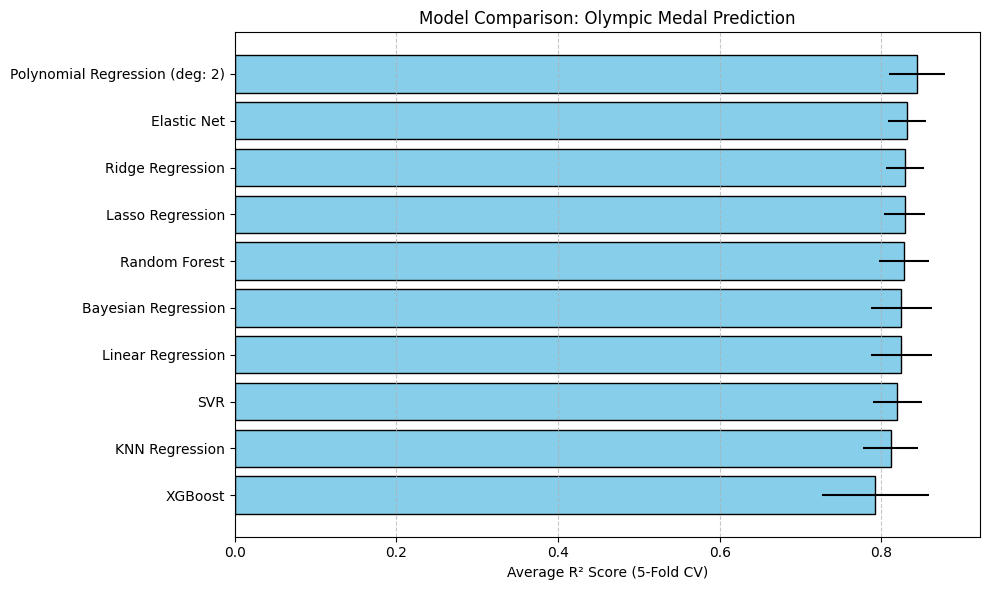

In [17]:
results.sort(key=lambda x: x[1], reverse=True)

names = [r[0] for r in results]
mean_scores = [r[1] for r in results]
std_scores = [r[2] for r in results]

plt.figure(figsize=(10, 6))
plt.barh(names, mean_scores, xerr=std_scores, color='skyblue', edgecolor='black')
plt.xlabel("Average R² Score (5-Fold CV)")
plt.title("Model Comparison: Olympic Medal Prediction")
plt.gca().invert_yaxis()  # Highest at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Polynomial PERFORMANCE SUMMARY
Metric               Training     Test         Difference  
------------------------------------------------------------
R² Score             0.8820       0.9224       -0.0404     
MAE                  4.2361       3.9249       0.3111      
RMSE                 11.3364      9.2268       2.1096      
Mean Abs Error       4.2361       3.9249       0.3111      


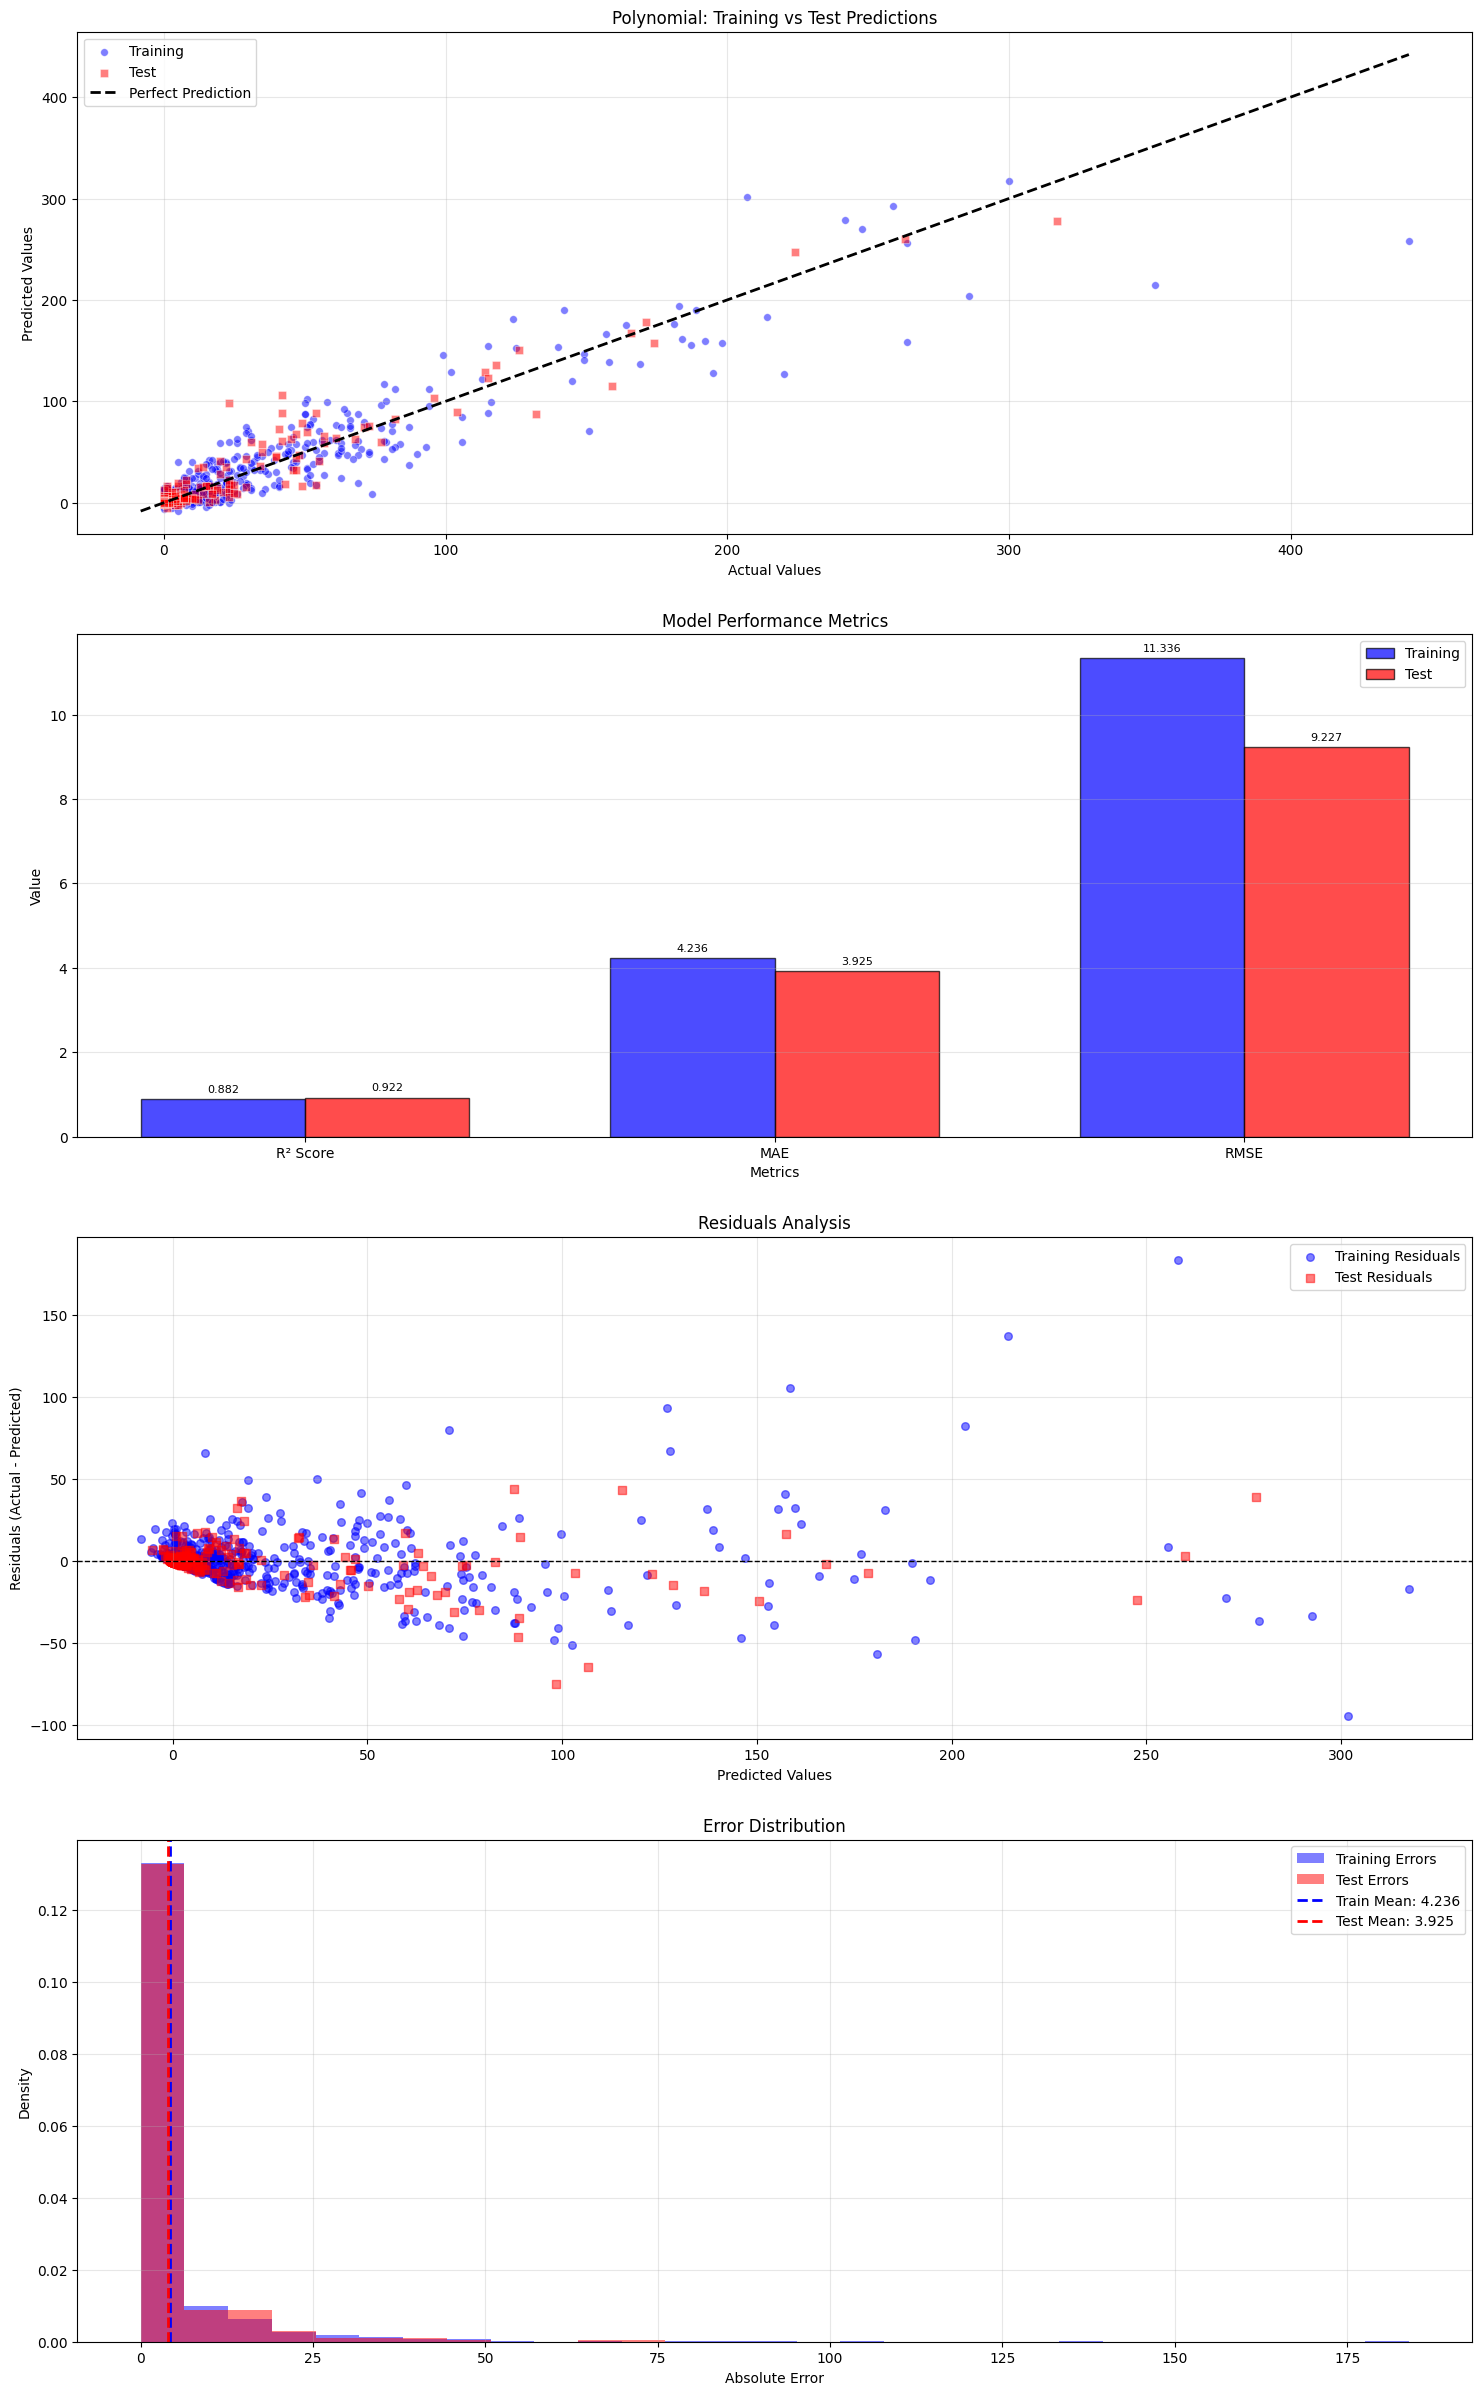

In [18]:
train_and_visualize_model(
    X, y,
    make_pipeline(
            PolynomialFeatures(degree=2, include_bias=False),
            LinearRegression()
        ),
    model_name="Polynomial"
)


Elastic Net PERFORMANCE SUMMARY
Metric               Training     Test         Difference  
------------------------------------------------------------
R² Score             0.8516       0.8978       -0.0461     
MAE                  5.0403       4.9624       0.0779      
RMSE                 12.7086      10.5869      2.1217      
Mean Abs Error       5.0403       4.9624       0.0779      


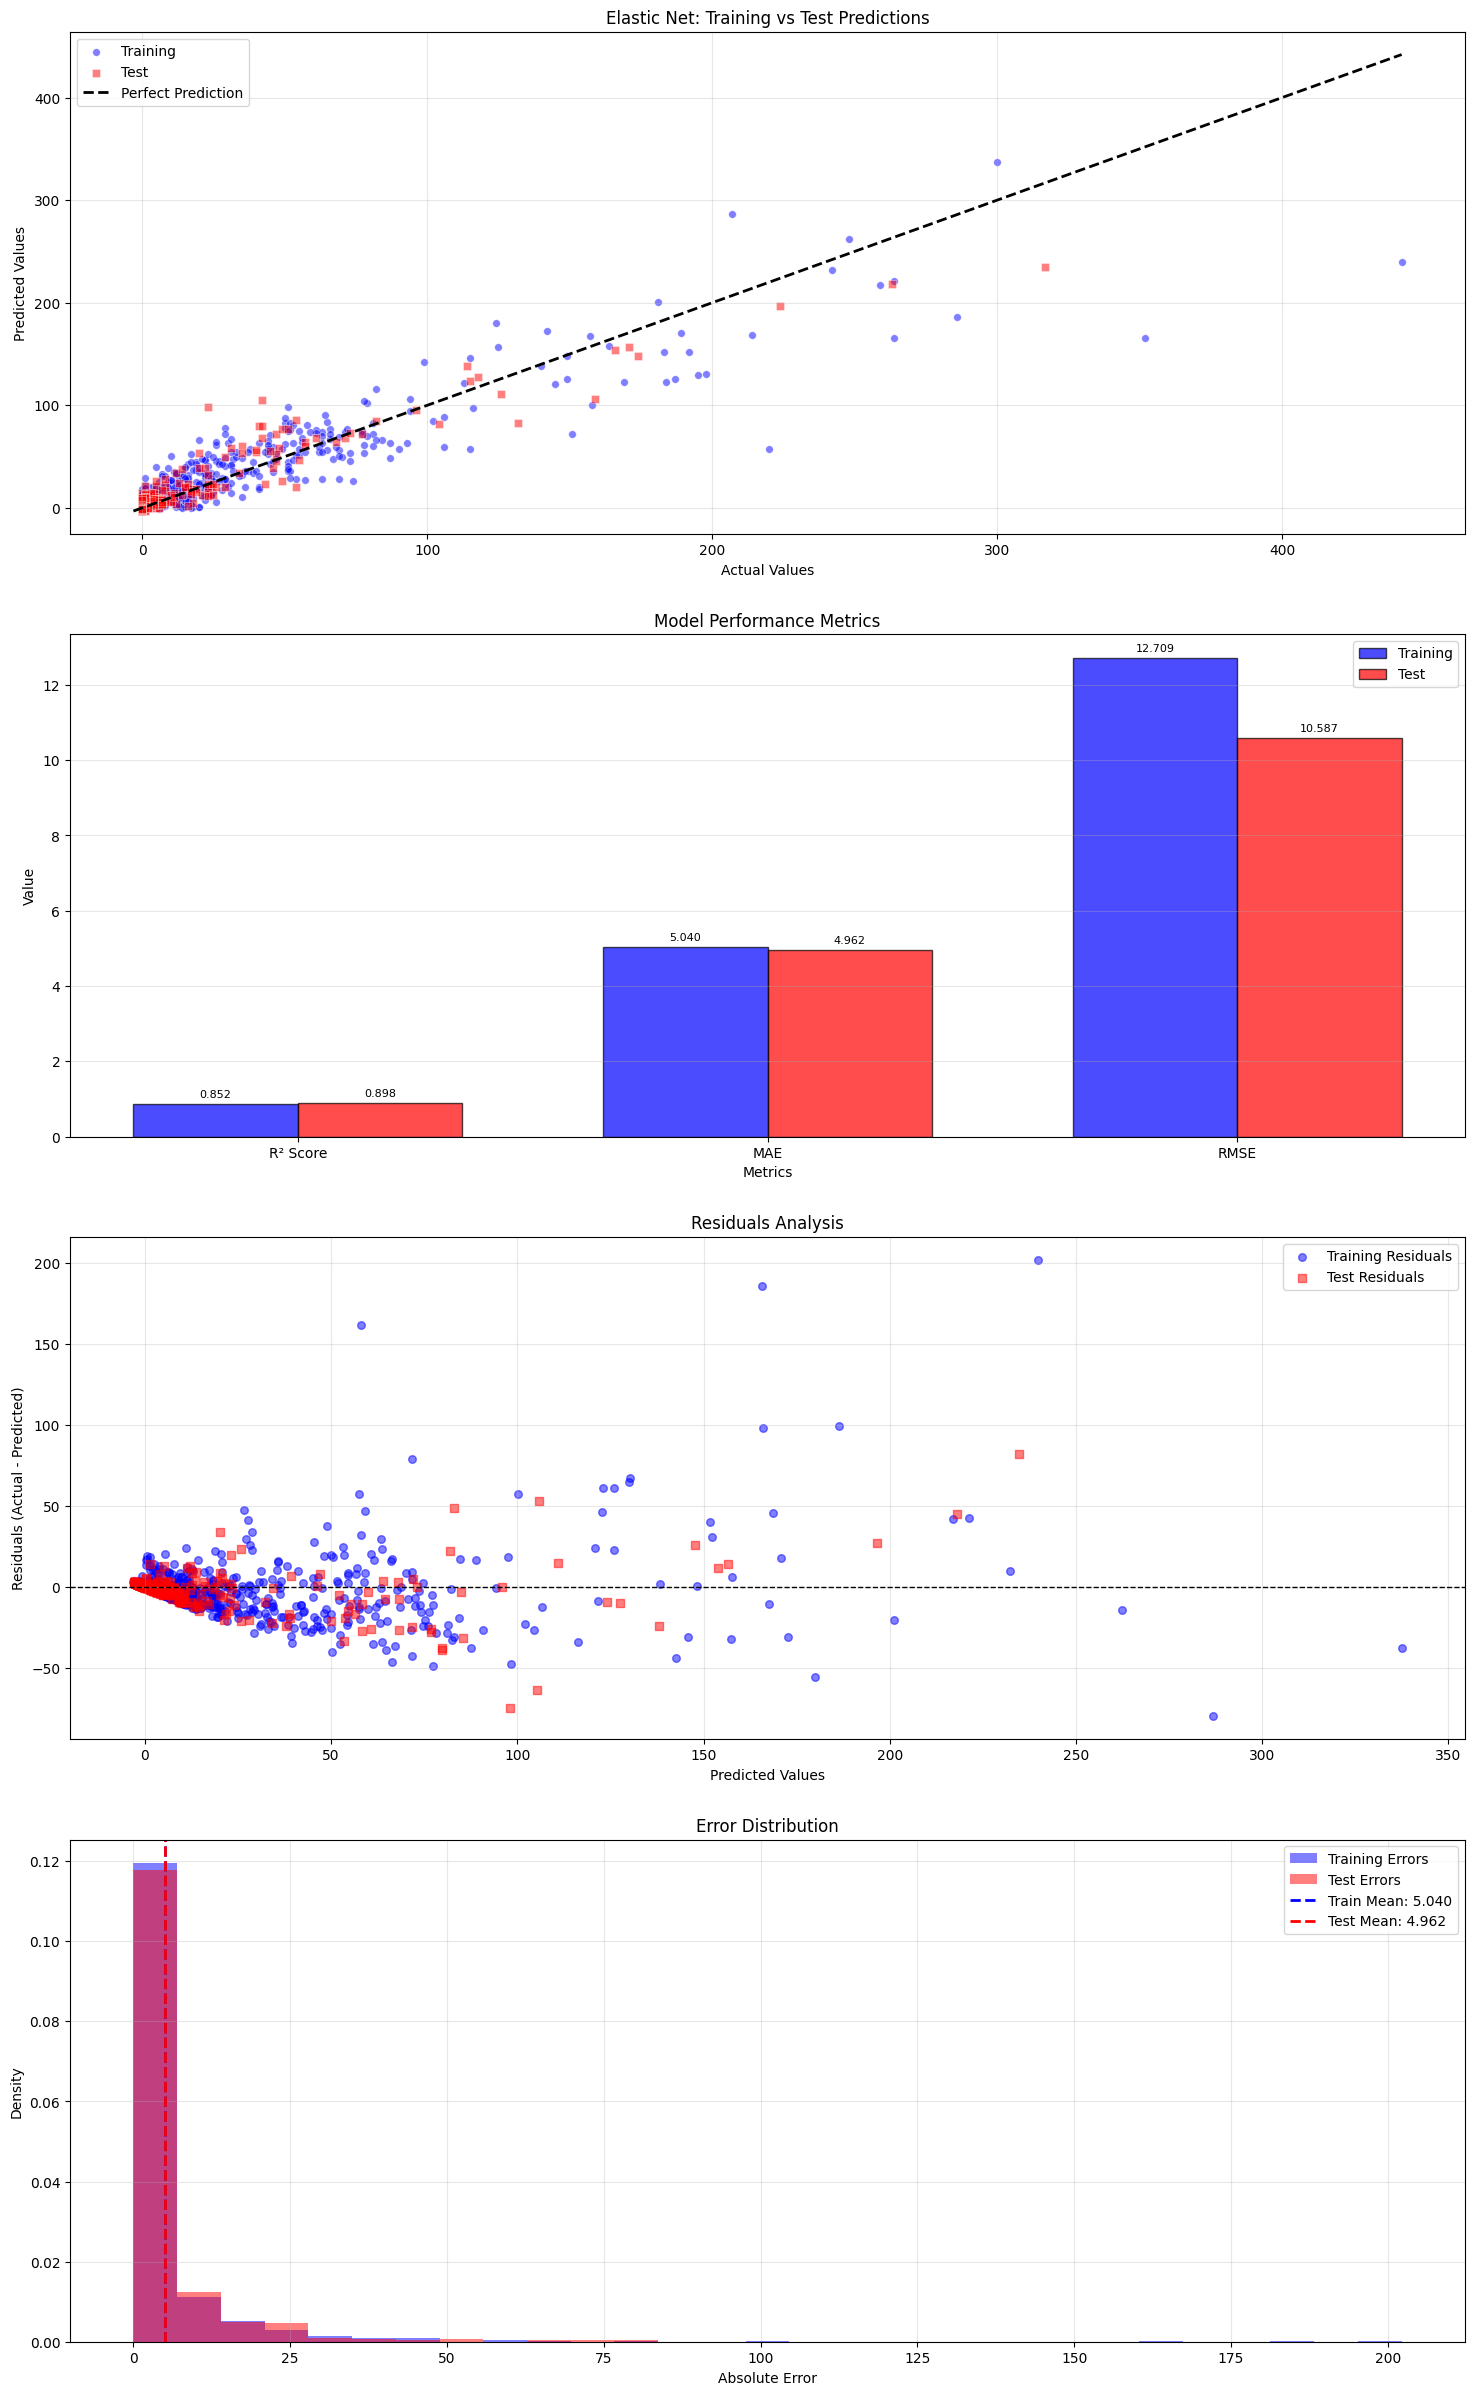

In [19]:
train_and_visualize_model(
    X, y,
    ElasticNet(alpha=0.1, l1_ratio=0.5),
    model_name="Elastic Net"
)


Ridge PERFORMANCE SUMMARY
Metric               Training     Test         Difference  
------------------------------------------------------------
R² Score             0.8326       0.8795       -0.0469     
MAE                  4.8989       4.8987       0.0002      
RMSE                 13.4994      11.4955      2.0039      
Mean Abs Error       4.8989       4.8987       0.0002      


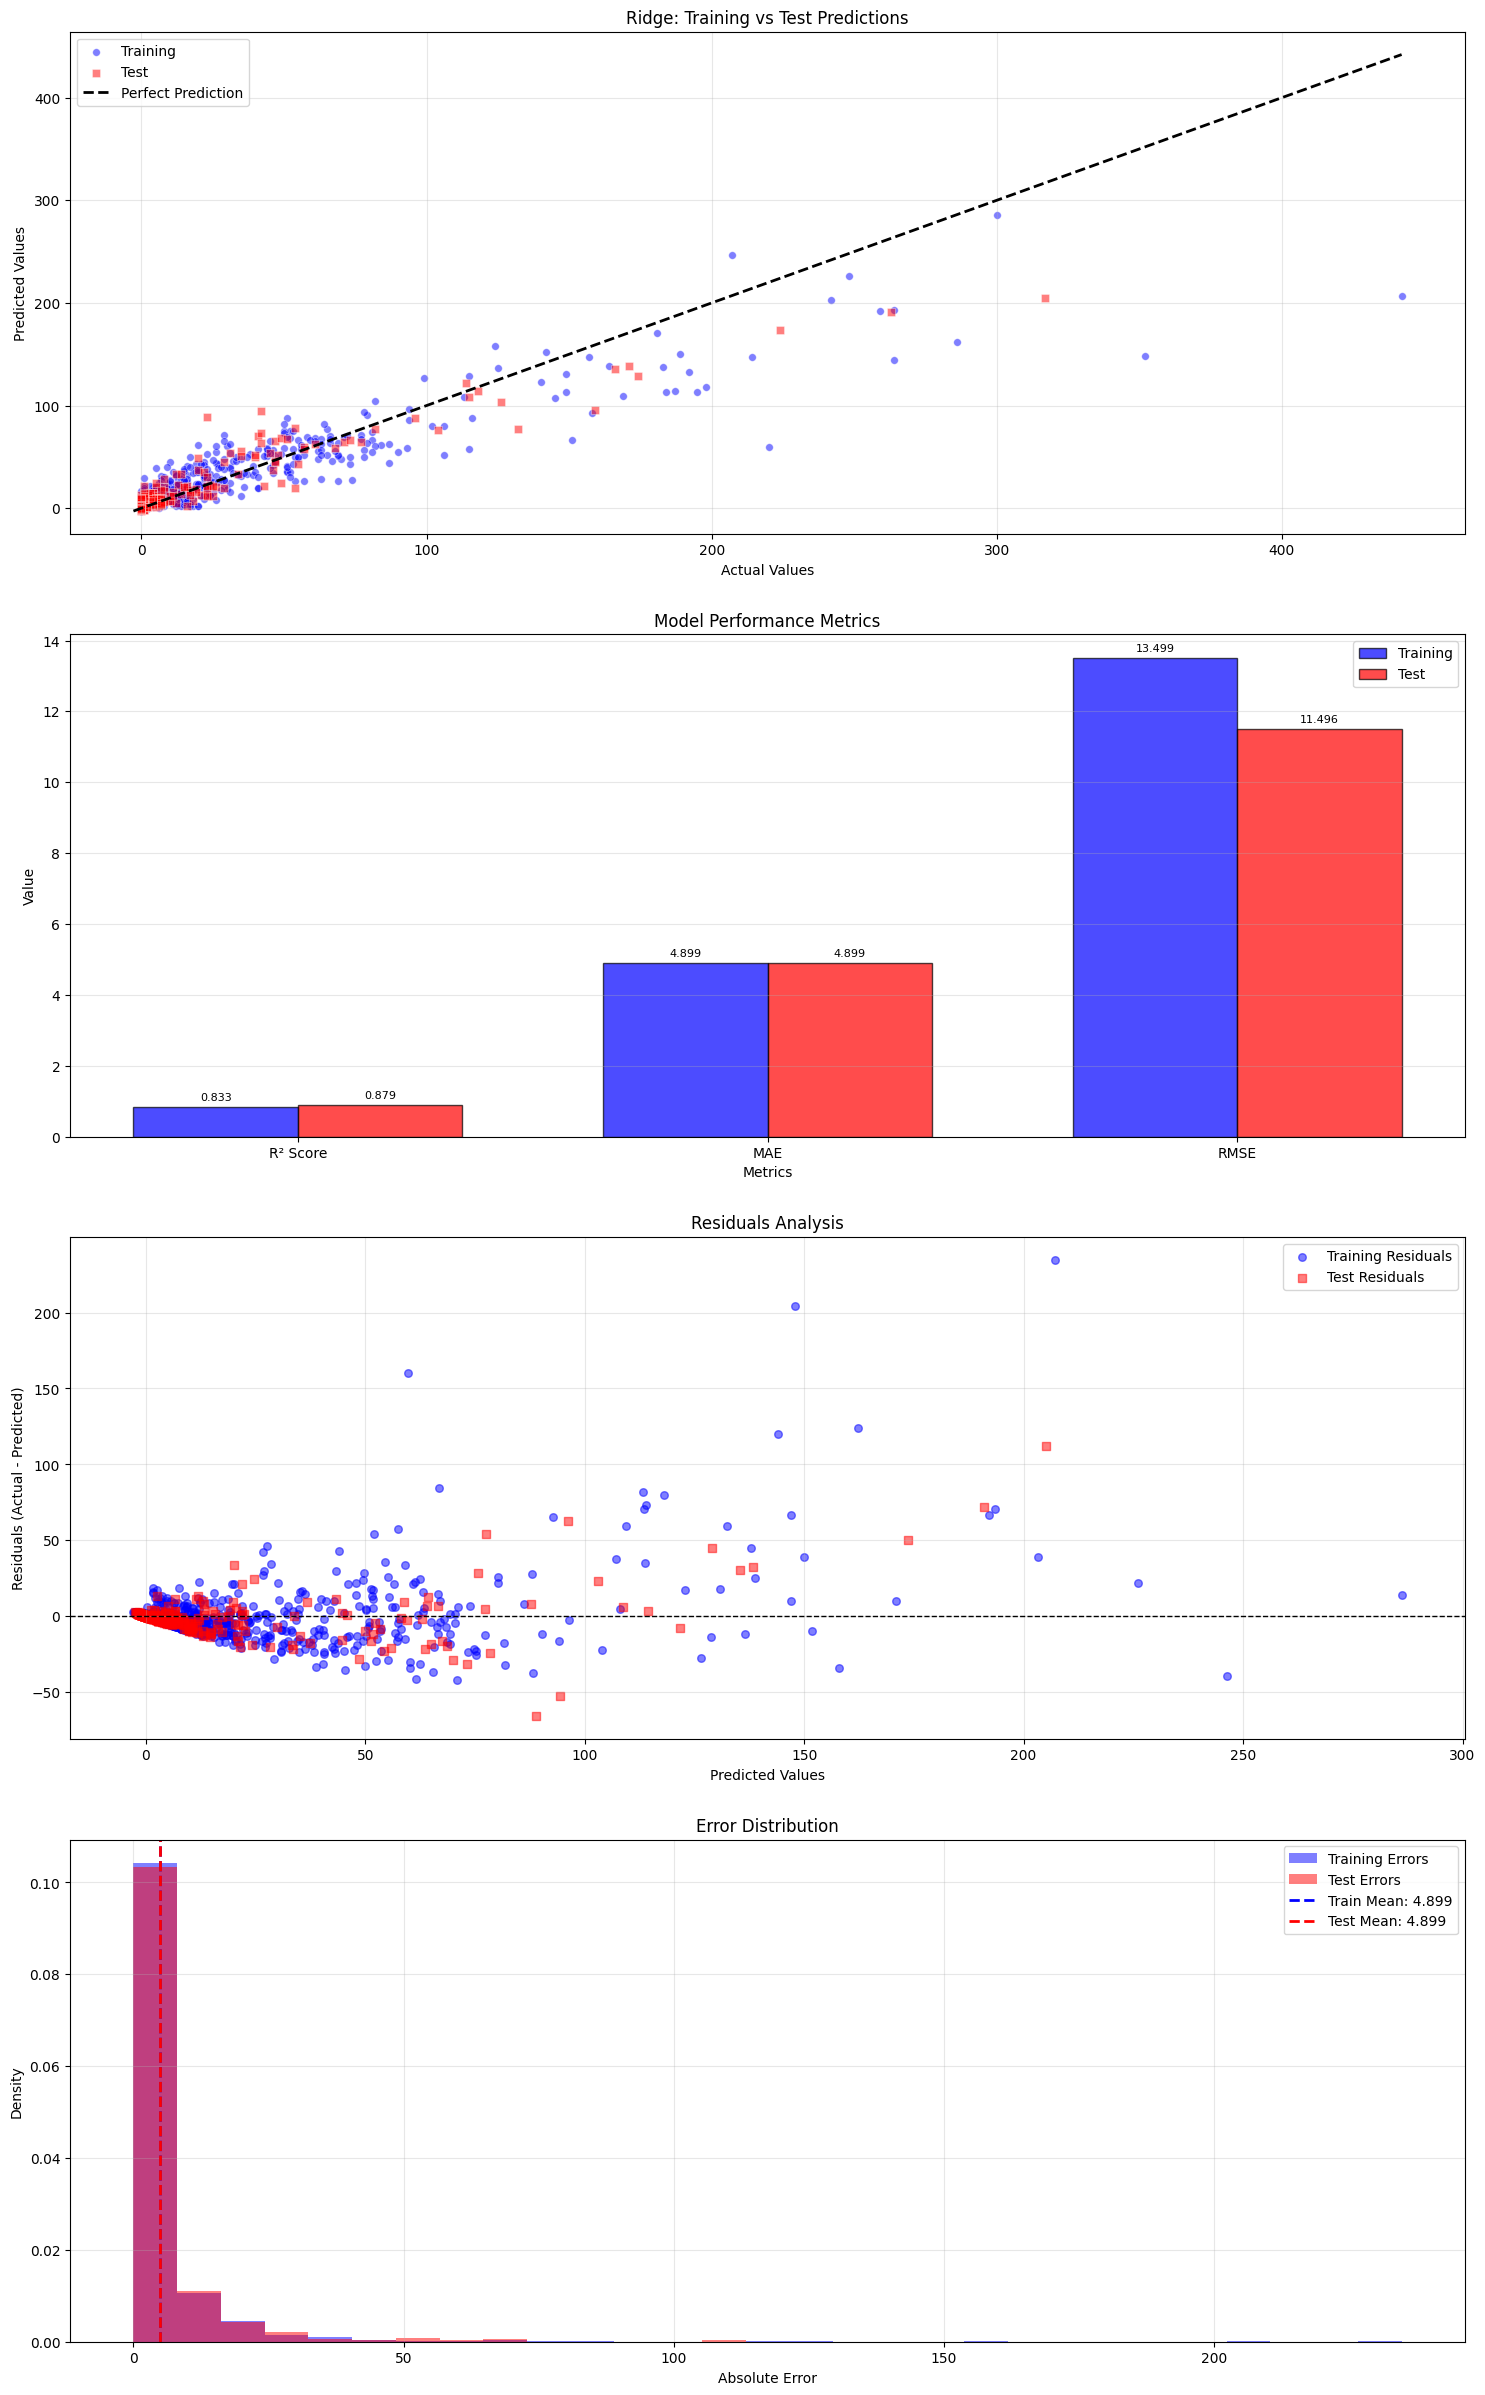

In [20]:
train_and_visualize_model(
    X, y,
    Ridge(alpha=500.0),
    model_name="Ridge"
)

##  8. Conclusion 📌

In this project, we aimed to predict the number of Olympic medals a team would win using a variety of regression models. 

We evaluated seven models using 5-fold cross-validation:
- Linear Regression
- Ridge Regression
- Lasso Regression
- Elastic Net Regression
- Support Vector Regression (SVR)
- Random Forest Regression
- XGBoost Regression
- Bayesian Regression
- Polynomial Regression
- K-Nearest Neighbors Regression

Among all the models tested, **Polynomial Regression (degree 2)** achieved **the highest average R²** score of **0.828**, outperforming every classical and modern model in terms of predictive accuracy. This indicates that the relationship between a country’s features and its medal count is nonlinear, and that adding polynomial interactions allows the model to capture patterns that linear models cannot.

However, the polynomial model also showed **slightly higher variance** *(std ≈ 0.034)* compared to regularized linear models such as Ridge or Elastic Net, meaning it is a bit more sensitive across different folds and may be more prone to overfitting.

Regularized linear models (Ridge, Lasso, Elastic Net) demonstrated the **highest stability**, with the lowest standard deviations *(~0.023–0.025)*, confirming that the underlying structure of the problem is mostly linear with moderate benefit from regularization.

Tree-based models like Random Forest and XGBoost were competitive but did not surpass classical regression methods, likely due to the moderate dataset size and the absence of complex nonlinear feature interactions.

### Predicted vs Actual Evaluation

The comparison between actual and predicted medal counts shows that the polynomial model captures the general trend well, with predictions closely following the true values. Residuals remained relatively small and evenly distributed, indicating no major systematic errors.

### ✅ Key Takeaways:
- **Best Accuracy**:
    **Polynomial Regression (degree 2)** — captures important nonlinear relationships.
- **Most stable and robust**:
    **Ridge / Elastic Net** — lowest variance across folds, excellent consistency.
- **Interpretability vs performance**:
    Linear models remain easy to interpret, but polynomial features substantially increase predictive power.
- **Tree-based models**:
    Performed solidly but did not outperform the best regression models for this dataset.
- **SVR and KNN**:
    More sensitive to hyperparameters and data scaling; underperformed relative to other methods.

**Polynomial Regression (degree 2)** is the best-performing model for this dataset, providing the highest predictive accuracy. For applications requiring robustness and interpretability, **Ridge or Elastic Net** offer an excellent alternative with very stable performance.